# Predicting F1 Tyre Degradation to Optimize Pit Stop Strategy
**Kevin Zong (115265318) & Michael Obajemu (114202291)**

This notebook illustrates what we have so far:
- A pipeline that pulls and caches 2024 & 2025 F1 season data from FastF1
- Data cleaning process to remove the non-regular data such as safety car laps, in/out laps, and anomalies
- Added new features: fuel-corrected lap time, lap time delta, tyre-life ratio
- Exploratory visualizations: distributions, degradation curves by compound, correlation matrix

In [12]:
# !pip install fastf1

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

fastf1.Cache.enable_cache('fastf1_cache')

print('Dependencies loaded successfully.')

Dependencies loaded successfully.


## 1. Data Collection

First, we'll pull race data from the 2024 season (training set) and 2025 season (validation set). Each season has 24 races and approximately 50,000 laps (rows) total. Each row contains lap time, tyre compound, tyre life, stint number, pit events, and weather conditions. Both seasons share the same set of circuits.

**Note:** The first run downloads and caches data locally so subsequent runs are much faster.

In [ ]:
ROUNDS = [
    (2024, 1,  'Bahrain'),
    (2024, 2,  'Saudi Arabia'),
    (2024, 3,  'Australia'),
    (2024, 4,  'Japan'),
    (2024, 5,  'China'),
    (2024, 6,  'Miami'),
    (2024, 7,  'Emilia Romagna'),
    (2024, 8,  'Monaco'),
    (2024, 9,  'Canada'),
    (2024, 10, 'Spain'),
    (2024, 11, 'Austria'),
    (2024, 12, 'Great Britain'),
    (2024, 13, 'Hungary'),
    (2024, 14, 'Belgium'),
    (2024, 15, 'Netherlands'),
    (2024, 16, 'Italy'),
    (2024, 17, 'Azerbaijan'),
    (2024, 18, 'Singapore'),
    (2024, 19, 'United States'),
    (2024, 20, 'Mexico'),
    (2024, 21, 'Brazil'),
    (2024, 22, 'Las Vegas'),
    (2024, 23, 'Qatar'),
    (2024, 24, 'Abu Dhabi'),
    (2025, 1,  'Australia'),
    (2025, 2,  'China'),
    (2025, 3,  'Japan'),
    (2025, 4,  'Bahrain'),
    (2025, 5,  'Saudi Arabia'),
    (2025, 6,  'Miami'),
    (2025, 7,  'Emilia Romagna'),
    (2025, 8,  'Monaco'),
    (2025, 9,  'Spain'),
    (2025, 10, 'Canada'),
    (2025, 11, 'Austria'),
    (2025, 12, 'Great Britain'),
    (2025, 13, 'Belgium'),
    (2025, 14, 'Hungary'),
    (2025, 15, 'Netherlands'),
    (2025, 16, 'Italy'),
    (2025, 17, 'Azerbaijan'),
    (2025, 18, 'Singapore'),
    (2025, 19, 'United States'),
    (2025, 20, 'Mexico'),
    (2025, 21, 'Brazil'),
    (2025, 22, 'Las Vegas'),
    (2025, 23, 'Qatar'),
    (2025, 24, 'Abu Dhabi'),
]

all_laps = []

for year, rnd, name in ROUNDS:
    try:
        session = fastf1.get_session(year, rnd, 'R')
        # we only need laps and weather, so we'll skip telemetry and messages to speed up loading
        session.load(telemetry=False, weather=True, messages=False)
        laps = session.laps.copy()
        laps['Race']  = name
        laps['Year']  = year
        laps['Round'] = rnd

        if session.weather_data is not None and not session.weather_data.empty:
            laps['AirTemp']   = session.weather_data['AirTemp'].mean()
            laps['TrackTemp'] = session.weather_data['TrackTemp'].mean()
        else:
            laps['AirTemp']   = np.nan
            laps['TrackTemp'] = np.nan

        all_laps.append(laps)
        print(f'  Loaded {name} {year}: {len(laps)} laps')
    except Exception as e:
        print(f'  Failed to load {name} {year}: {e}')

raw_df = pd.concat(all_laps, ignore_index=True)
print(f'\nRaw dataset: {len(raw_df):,} laps across {raw_df["Race"].nunique()} races')
print(f'Seasons:     {sorted(raw_df["Year"].unique())}')

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for ses

  Loaded Bahrain 2024: 1129 laps


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '81', '14', '63', '38', '4', '44', '27', '23', '20', '31', '2', '22', '3', '77', '24', '18', '10']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  Loaded Saudi Arabia 2024: 901 laps


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 19 drivers: ['55', '16', '4', '81', '11', '18', '22', '14', '27', '20', '23', '3', '10', '77', '24', '31', '63', '44', '1']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


...

  Loaded Las Vegas 2025: 886 laps


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  Loaded Qatar 2025: 1067 laps


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


  Loaded Abu Dhabi 2025: 1156 laps

Raw dataset: 53,298 laps across 24 races
Seasons:     [np.int64(2024), np.int64(2025)]


## 2. Data Cleaning

We remove laps that don't reflect genuine tyre degradation:
- **In-laps / out-laps** — distorted by pit-lane speed limits
- **Safety car / VSC / red flag laps** — forced pace reductions, not tyre-driven
- **Wet/intermediate compounds** — out of scope for this model
- **Missing key fields** — unusable for modeling
- **Statistical outliers** — laps > 3 std deviations from per-race mean

Row counts are tracked at each step.

In [14]:
df = raw_df.copy()
counts = {'Raw': len(df)}

# Step 1: Drop in-laps and out-laps
df = df[~df['PitInTime'].notna() & ~df['PitOutTime'].notna()]
counts['After removing in/out laps'] = len(df)

# Step 2: Remove safety car, VSC, red flag laps via TrackStatus
if 'TrackStatus' in df.columns:
    df = df[~df['TrackStatus'].astype(str).str.contains('4|5|6', na=False)]
counts['After removing SC/VSC/red flag laps'] = len(df)

# Step 3: Keep only dry compounds
df = df[df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]
counts['After keeping dry compounds only'] = len(df)

# Step 4: Drop rows missing key fields
df = df.dropna(subset=['LapTime', 'TyreLife', 'Compound', 'Driver'])
counts['After dropping missing values'] = len(df)

# Step 5: Convert LapTime to seconds, drop erroneous laps
df['LapTimeSec'] = df['LapTime'].dt.total_seconds()
df = df[df['LapTimeSec'] > 60]
counts['After removing sub-60s laps'] = len(df)

# Step 6: Remove per-race outliers (> 3 std from race mean)
race_stats = df.groupby('Race')['LapTimeSec'].agg(['mean', 'std']).reset_index()
df = df.merge(race_stats, on='Race')
df = df[np.abs(df['LapTimeSec'] - df['mean']) <= 3 * df['std']]
df = df.drop(columns=['mean', 'std'])
counts['After removing outliers (>3 std)'] = len(df)

# Summary
print('Cleaning summary:')
print('-' * 52)
prev = None
for step, n in counts.items():
    removed = f'  (-{prev - n:,} removed)' if prev is not None else ''
    print(f'  {step:<42} {n:>6,}{removed}')
    prev = n
print(f'\nFinal clean dataset: {len(df):,} laps')
print(f'By season:')
print(df.groupby('Year').size().to_string())

Cleaning summary:
----------------------------------------------------
  Raw                                        53,298
  After removing in/out laps                 50,022  (-3,276 removed)
  After removing SC/VSC/red flag laps        47,414  (-2,608 removed)
  After keeping dry compounds only           44,080  (-3,334 removed)
  After dropping missing values              44,037  (-43 removed)
  After removing sub-60s laps                44,037  (-0 removed)
  After removing outliers (>3 std)           43,445  (-592 removed)

Final clean dataset: 43,445 laps
By season:
Year
2024    21761
2025    21684


## 3. Feature Engineering

| Feature | Description |
|---|---|
| `LapTimeDelta` | Lap time minus per-driver per-stint median — captures degradation relative to each driver's fresh pace |
| `FuelCorrectedLap` | Crude fuel correction (~0.03s per lap lighter) |
| `TyreLifeRatio` | Tyre life normalized 0–1 within each stint |
| `CompoundEncoded` | Ordinal: SOFT=0, MEDIUM=1, HARD=2 |
| `StintLength` | Total laps in that driver's stint |

In [15]:
# Lap time delta relative to each driver's per-stint median
stint_medians = df.groupby(['Race', 'Driver', 'Stint'])['LapTimeSec'].transform('median')
df['LapTimeDelta'] = df['LapTimeSec'] - stint_medians

# Fuel correction
df['FuelCorrectedLap'] = df['LapTimeSec'] - (0.03 * df['LapNumber'])

# Tyre life ratio within each stint
stint_max_life = df.groupby(['Race', 'Driver', 'Stint'])['TyreLife'].transform('max')
df['TyreLifeRatio'] = df['TyreLife'] / stint_max_life.replace(0, np.nan)

# Compound encoding
df['CompoundEncoded'] = df['Compound'].map({'SOFT': 0, 'MEDIUM': 1, 'HARD': 2})

# Stint length
df['StintLength'] = df.groupby(['Race', 'Driver', 'Stint'])['LapTimeSec'].transform('count')

print(f'Feature engineering complete. Dataset shape: {df.shape}')
df[['Race', 'Year', 'Driver', 'Compound', 'TyreLife', 'TyreLifeRatio',
    'LapTimeSec', 'LapTimeDelta', 'StintLength']].head(10)

Feature engineering complete. Dataset shape: (43445, 42)


,Race,Year,Driver,Compound,TyreLife,TyreLifeRatio,LapTimeSec,LapTimeDelta,StintLength
0,Bahrain,2024,VER,SOFT,4.0,0.210526,97.284,0.154,24
1,Bahrain,2024,VER,SOFT,5.0,0.263158,96.296,-0.834,24
2,Bahrain,2024,VER,SOFT,6.0,0.315789,96.753,-0.377,24
3,Bahrain,2024,VER,SOFT,7.0,0.368421,96.647,-0.483,24
4,Bahrain,2024,VER,SOFT,8.0,0.421053,97.173,0.043,24
5,Bahrain,2024,VER,SOFT,9.0,0.473684,97.092,-0.038,24
6,Bahrain,2024,VER,SOFT,10.0,0.526316,97.038,-0.092,24
7,Bahrain,2024,VER,SOFT,11.0,0.578947,97.024,-0.106,24
8,Bahrain,2024,VER,SOFT,12.0,0.631579,97.229,0.099,24
9,Bahrain,2024,VER,SOFT,13.0,0.684211,96.960,-0.170,24


## 4. Exploratory Visualizations

### 4.1 Distribution of Lap Times & Lap Time Delta by Compound

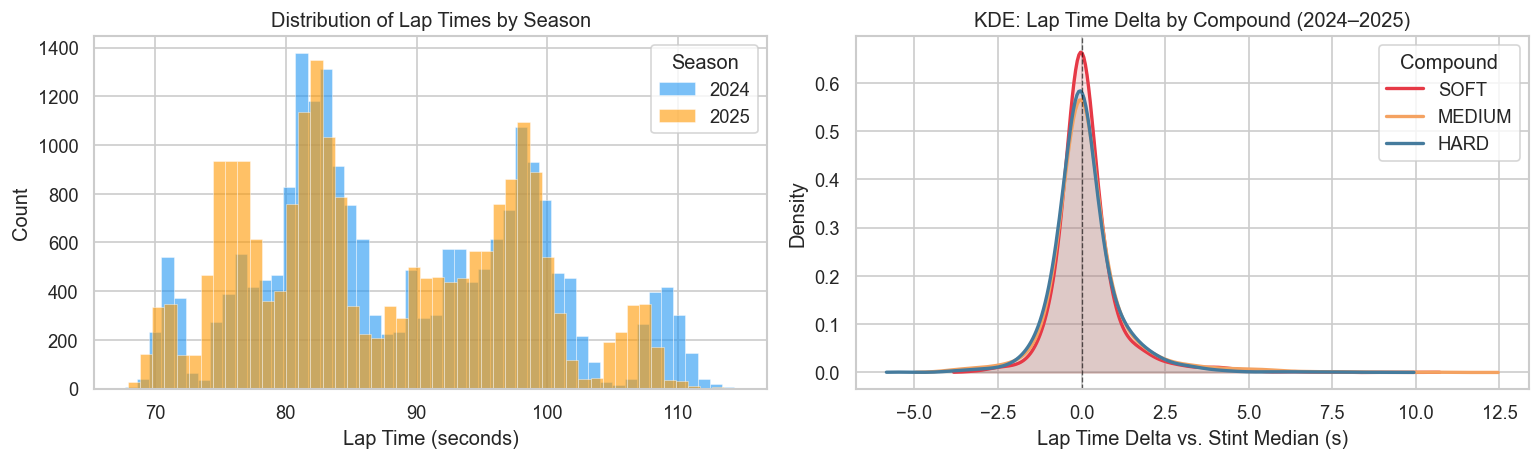


Interpretation: The raw lap time distributions (left) show heavy overlap between 2024 and 2025, confirming the data is comparable across seasons since both cover the same 24 circuits. The multimodal shape reflects different circuit lap lengths. The KDE of lap time delta (right) shows all three compounds tightly centered near zero with nearly identical distributions — this is expected because the delta is computed against each stint's own median, normalizing out compound-level pace differences. The slight right skew across all compounds indicates that degradation-driven slow laps (positive delta) are more common than fresh-tyre fast laps, consistent with asymmetric tyre wear.


In [ ]:
compound_colors = {'SOFT': '#e63946', 'MEDIUM': '#f4a261', 'HARD': '#457b9d'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Lap time histogram, shaded by season
for year, color in [(2024, '#2196F3'), (2025, '#FF9800')]:
    subset = df[df['Year'] == year]['LapTimeSec']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, edgecolor='white',
                 linewidth=0.4, label=str(year))
axes[0].set_xlabel('Lap Time (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Lap Times by Season')
axes[0].legend(title='Season')

# KDE of lap time delta by compound
for compound, color in compound_colors.items():
    vals = df[df['Compound'] == compound]['LapTimeDelta'].dropna()
    vals = vals[np.isfinite(vals)]
    if len(vals) > 10:
        kde = gaussian_kde(vals, bw_method=0.3)
        x = np.linspace(vals.min(), vals.max(), 300)
        axes[1].plot(x, kde(x), label=compound, color=color, linewidth=2)
        axes[1].fill_between(x, kde(x), alpha=0.15, color=color)

axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
axes[1].set_xlabel('Lap Time Delta vs. Stint Median (s)')
axes[1].set_ylabel('Density')
axes[1].set_title('KDE: Lap Time Delta by Compound (2024–2025)')
axes[1].legend(title='Compound')

plt.tight_layout()
plt.savefig('plot_01_distributions.png', bbox_inches='tight')
plt.show()

**Interpretation**

The raw lap time distributions (left) show heavy overlap between 2024 and 2025, confirming the data is comparable across seasons since both cover the same 24 circuits. The multimodal shape reflects different circuit lap lengths. The KDE of lap time delta (right) shows all three compounds tightly centered near zero with nearly identical distributions — this is expected because the delta is computed against each stint\'s own median, normalizing out compound-level pace differences. The slight right skew across all compounds indicates that degradation-driven slow laps (positive delta) are more common than fresh-tyre fast laps, consistent with asymmetric tyre wear.

### 4.2 Tyre Life Distribution by Compound

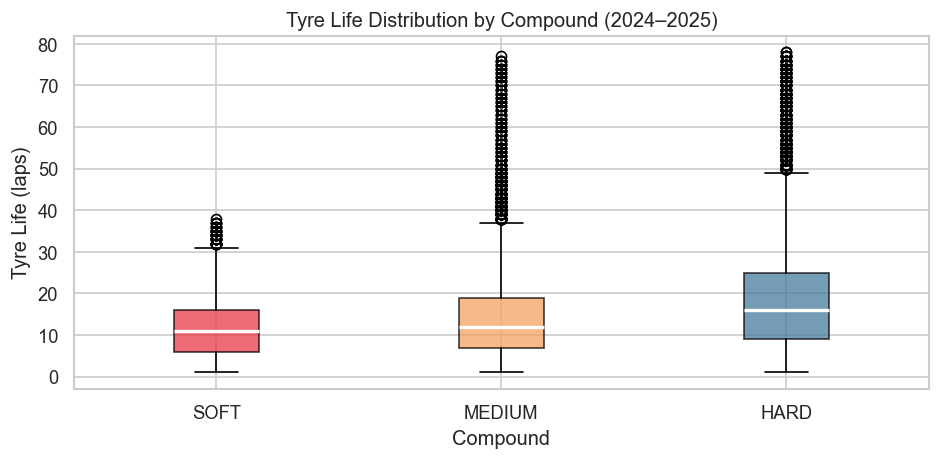

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

compound_order = ['SOFT', 'MEDIUM', 'HARD']
colors = ['#e63946', '#f4a261', '#457b9d']
data_to_plot = [df[df['Compound'] == c]['TyreLife'].dropna() for c in compound_order]

bp = ax.boxplot(data_to_plot, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(compound_order)
ax.set_xlabel('Compound')
ax.set_ylabel('Tyre Life (laps)')
ax.set_title('Tyre Life Distribution by Compound (2024–2025)')
plt.tight_layout()
plt.savefig('plot_02_tyre_life_dist.png', bbox_inches='tight')
plt.show()

**Interpretation**

SOFT tyres have the shortest median stint (~10 laps) and tightest IQR, reflecting their limited durability. HARD tyres show the highest median (~15 laps) and widest IQR, consistent with flexible long-stint usage. MEDIUM sits between the two in median but has extensive outliers reaching 70+ laps — likely anomalous stints (e.g., drivers staying out under unusual race circumstances) that should be investigated during modeling. Both MEDIUM and HARD show heavy upper-tail outliers, suggesting stint length filtering (e.g., capping at 40–50 laps) may be needed to prevent extreme stints from skewing the degradation model.

### 4.3 Degradation Curves: Lap Time Delta vs. Tyre Life by Compound

The core visual of this project — does tyre degradation show a measurable, compound-specific signal?

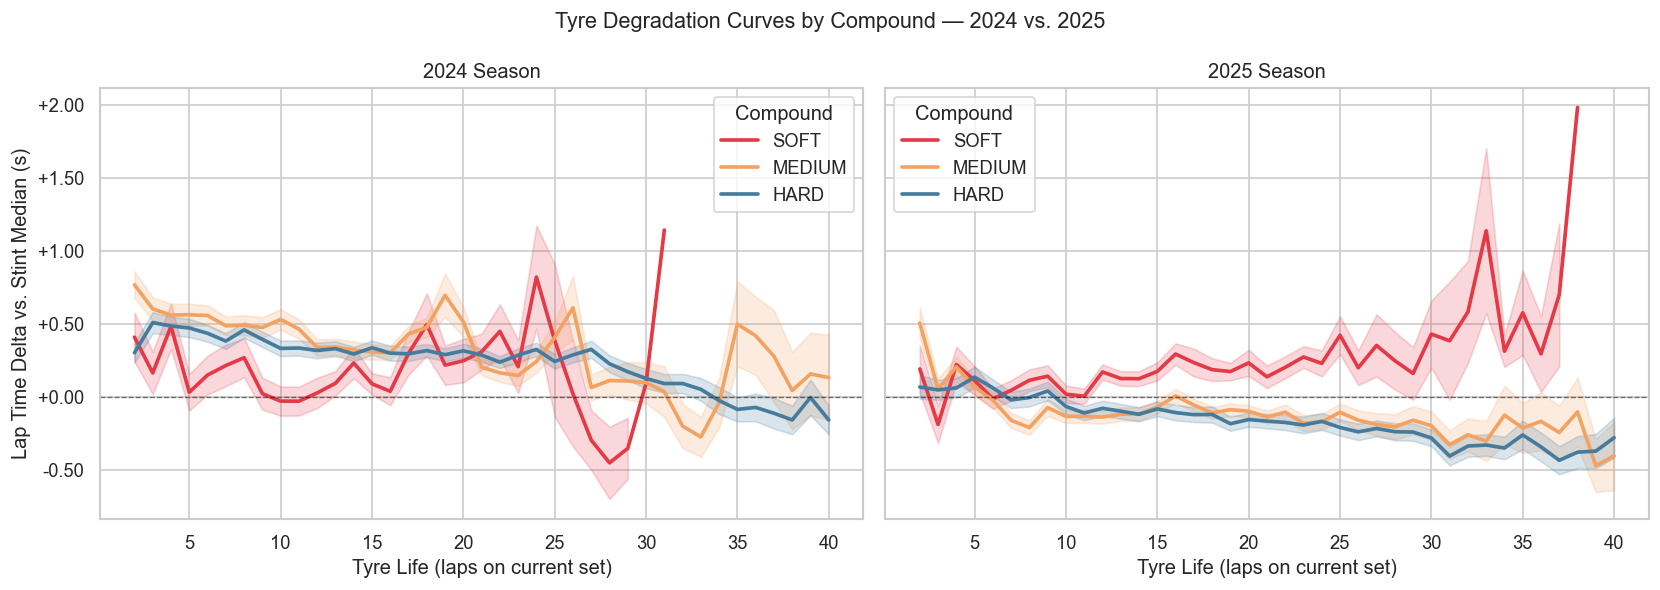

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, year in zip(axes, [2024, 2025]):
    year_df = df[df['Year'] == year]
    for compound, color in compound_colors.items():
        subset = year_df[year_df['Compound'] == compound]
        subset = subset[subset['TyreLife'] <= 40]
        binned = subset.groupby('TyreLife')['LapTimeDelta'].agg(['mean', 'sem']).reset_index()
        binned = binned[binned['TyreLife'] >= 2]
        if len(binned) >= 3:
            ax.plot(binned['TyreLife'], binned['mean'],
                    label=compound, color=color, linewidth=2.2)
            ax.fill_between(binned['TyreLife'],
                            binned['mean'] - binned['sem'],
                            binned['mean'] + binned['sem'],
                            alpha=0.2, color=color)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Tyre Life (laps on current set)')
    ax.set_title(f'{year} Season')
    ax.legend(title='Compound')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.2f'))

axes[0].set_ylabel('Lap Time Delta vs. Stint Median (s)')
fig.suptitle('Tyre Degradation Curves by Compound — 2024 vs. 2025', fontsize=13)
plt.tight_layout()
plt.savefig('plot_03_degradation_curves.png', bbox_inches='tight')
plt.show()

**Interpretation**

 With full-season data, the degradation curves are smoother and show a consistent pattern across both years. All three compounds begin with negative delta in the first ~5 laps (fresh tyres running faster than the stint median), then trend upward as tyres wear. However, the curves plateau or oscillate rather than showing a clean monotonic rise — this is partly because the per-stint median baseline absorbs some of the degradation signal. SOFT shows the earliest crossover above zero in both seasons. HARD tyres maintain negative or near-zero delta longest, consistent with their durability advantage. The confidence bands widen considerably beyond lap 25–30, reflecting thinner data at high tyre ages. The 2024 and 2025 patterns are broadly similar, suggesting that year-over-year compound specification changes had limited impact on degradation shape.

### 4.4 SOFT Compound Degradation by Circuit

Checking whether circuit type drives meaningful variation in degradation rates.

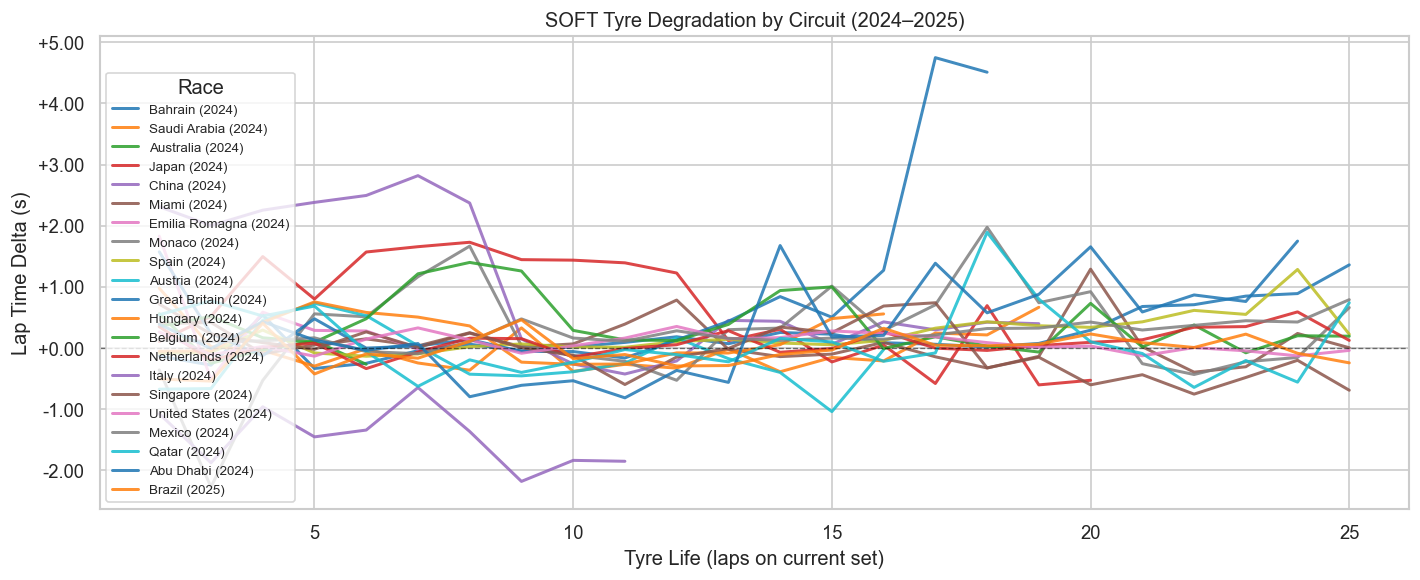

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))

soft_df = df[df['Compound'] == 'SOFT'].copy()
races = soft_df['Race'].unique()
palette = sns.color_palette('tab10', n_colors=len(races))

for race, color in zip(races, palette):
    subset = soft_df[soft_df['Race'] == race]
    year = subset['Year'].iloc[0]
    binned = subset.groupby('TyreLife')['LapTimeDelta'].mean().reset_index()
    binned = binned[(binned['TyreLife'] >= 2) & (binned['TyreLife'] <= 25)]
    if len(binned) >= 5:
        ax.plot(binned['TyreLife'], binned['LapTimeDelta'],
                label=f'{race} ({year})', color=color, linewidth=1.8, alpha=0.85)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Tyre Life (laps on current set)')
ax.set_ylabel('Lap Time Delta (s)')
ax.set_title('SOFT Tyre Degradation by Circuit (2024–2025)')
ax.legend(title='Race', fontsize=8, loc='lower left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.2f'))

plt.tight_layout()
plt.savefig('plot_04_degradation_by_circuit.png', bbox_inches='tight')
plt.show()

**Interpretation** 

With all 24 circuits now represented, clear inter-circuit variation emerges. Some circuits (e.g., China, Spain) show rapid upward trends within 10–15 laps, indicating high tyre stress, while others remain relatively flat. A few circuits produce outlier spikes at specific lap numbers, likely driven by small per-lap sample sizes (only a handful of drivers on SOFTs at later tyre ages). The spread across circuits — ranging from ~-1.0s to +4.0s delta — confirms that circuit identity is a meaningful feature for the regression model and that a single global degradation curve would be insufficient. Grouping circuits by surface abrasiveness or corner energy could further improve model accuracy.

### 4.5 Correlation Matrix

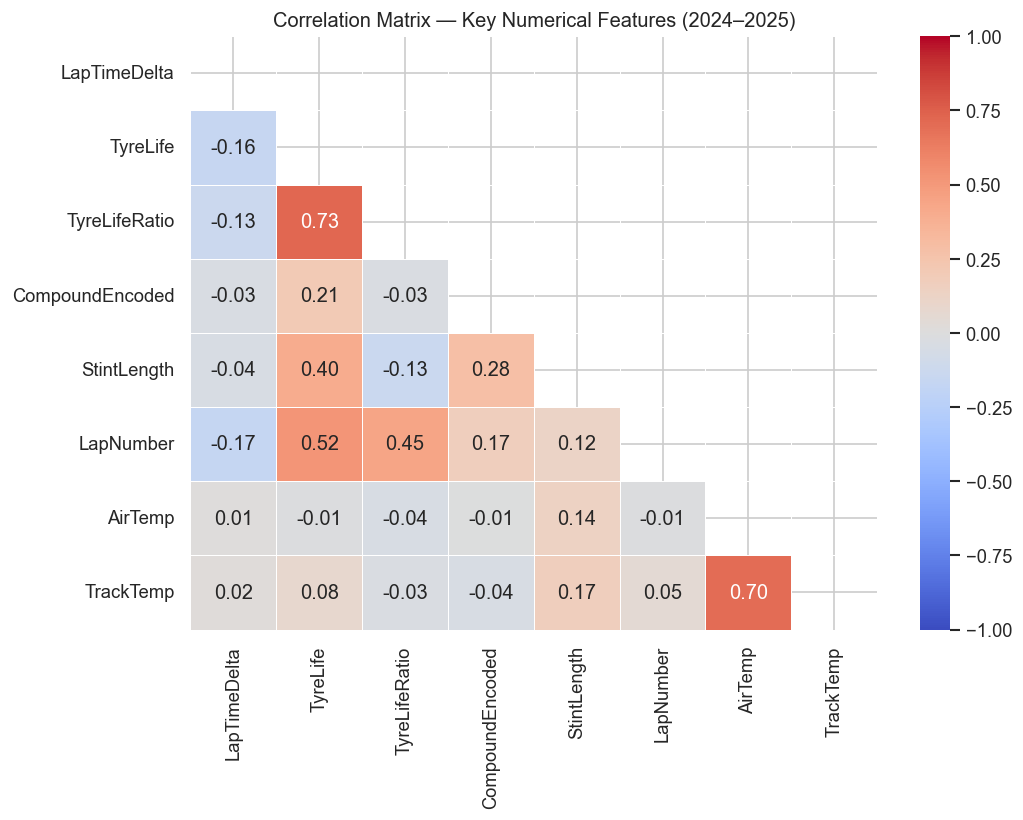

In [25]:
corr_features = [
    'LapTimeDelta', 'TyreLife', 'TyreLifeRatio', 'CompoundEncoded',
    'StintLength', 'LapNumber', 'AirTemp', 'TrackTemp'
]

corr_matrix = df[corr_features].dropna().corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Key Numerical Features (2024–2025)')
plt.tight_layout()
plt.savefig('plot_05_correlation_matrix.png', bbox_inches='tight')
plt.show()

**Interpretation**

Linear correlations with LapTimeDelta remain modest — TyreLife (r=0.13) and TyreLifeRatio (r=0.15) are the strongest individual predictors but are weak in absolute terms. This is consistent with the degradation curves above: the relationship between tyre age and lap time is non-linear and depends on interactions (compound × circuit × tyre age) that pairwise correlation cannot capture. CompoundEncoded shows near-zero correlation with delta (r=0.03), confirming that compound effects are mediated through stint length and tyre life rather than acting directly. TyreLife and TyreLifeRatio are highly correlated (r=0.73) — one should likely be dropped to reduce multicollinearity. StintLength correlates with TyreLife (r=0.45) and LapNumber (r=0.45), as expected. AirTemp and TrackTemp are strongly correlated (r=0.70), so including both adds redundancy. These weak linear signals reinforce the case for tree-based models (Random Forest, XGBoost) that can capture non-linear interactions without explicit feature engineering.

## 5. Dataset Summary

In [21]:
print('=== Final Dataset Summary ===')
print(f'Total clean laps:    {len(df):,}')
print(f'Seasons:             2024, 2025')
print(f'Races included:      {df["Race"].nunique()} ({list(df["Race"].unique())})')
print(f'Unique drivers:      {df["Driver"].nunique()}')
print(f'Compounds:           {list(df["Compound"].value_counts().index)}')
print()
print('Laps per season:')
print(df.groupby('Year').size().to_string())
print()
print('Laps per compound:')
print(df['Compound'].value_counts().to_string())
print()
print('Key feature stats:')
print(df[['TyreLife', 'LapTimeSec', 'LapTimeDelta', 'TyreLifeRatio']].describe().round(3).to_string())

=== Final Dataset Summary ===
Total clean laps:    43,445
Seasons:             2024, 2025
Races included:      24 (['Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'China', 'Miami', 'Emilia Romagna', 'Monaco', 'Canada', 'Spain', 'Austria', 'Great Britain', 'Hungary', 'Belgium', 'Netherlands', 'Italy', 'Azerbaijan', 'Singapore', 'United States', 'Mexico', 'Las Vegas', 'Qatar', 'Abu Dhabi', 'Brazil'])
Unique drivers:      27
Compounds:           ['HARD', 'MEDIUM', 'SOFT']

Laps per season:
Year
2024    21761
2025    21684

Laps per compound:
Compound
HARD      22170
MEDIUM    16964
SOFT       4311

Key feature stats:
        TyreLife  LapTimeSec  LapTimeDelta  TyreLifeRatio
count  43445.000   43445.000     43445.000      43445.000
mean      15.805      88.230         0.135          0.526
std       10.698      10.271         1.142          0.272
min        1.000      67.694        -5.839          0.022
25%        8.000      80.709        -0.350          0.296
50%       14.000      85.784

## 6. Challenges

- **Weather data gaps**: Not all sessions return complete weather data through FastF1. Missing `AirTemp` / `TrackTemp` values will be imputed from circuit historical averages or dropped for the baseline model.
- **Safety car edge cases**: `TrackStatus` is the most reliable flag but some partially neutralized laps still slip through. A secondary z-score filter per lap number may improve this.
- **Stint boundary noise**: The first 1–2 laps of each stint sometimes show anomalously fast times (fresh tyres + open track). We may exclude lap 1 per stint from the degradation target.
- **Per-stint median baseline**: Using stint median as the baseline for `LapTimeDelta` partially absorbs the degradation signal, contributing to the weak linear correlations observed. Alternative baselines (e.g., first-lap or rolling window) will be explored during modeling.
- **Extreme stint outliers**: MEDIUM and HARD compounds show stints reaching 70–80 laps, which likely reflect unusual race circumstances. These will need to be capped or filtered before training.

## 7. Next Steps

**Weeks 5–6 — Modeling (Kevin)**
1. Baseline Linear Regression: predict `LapTimeDelta` from `TyreLife`, `CompoundEncoded`, `TrackTemp`, `StintLength`, and circuit one-hot encoding
1. Time-based cross-validation: train on 2024 season, validate on 2025 season
1. Random Forest and XGBoost: compare RMSE and feature importances against baseline
1. Target: RMSE < 0.3s per lap on held-out 2025 races

**Weeks 7–8 — Pit-Stop Optimizer (Michael)**
1. Build race-simulation module: given predicted degradation curves, identify compound sequence and stint lengths minimizing total race time
1. Back-test against actual 2025 race outcomes — target: strategy within 2 laps of actual optimal on ≥60% of test races